# Exploratory Data Analysis

This notebook revisits Data Understanding on the *prepared* data. `01_data_understanding.ipynb` performed a quick numeric first look at the raw dataset.

This notebook produces the visual figures that support the report's dataset description and modelling justification sections: class balance, the missing-value profile, text length by class, fraud rate by structured metadata field, and the most distinctive words per class.

No cleaning, splitting, or model fitting happens here. Like `01_data_understanding.ipynb`, this notebook produces insight and figures, not files. The one exception is the missing-value chart, which uses a raw, pre-fill snapshot instead of `cleaned.csv`, since `02_data_preparation.ipynb` has already filled or dropped every column with meaningful missing values.

In [1]:
# Standard library
import sys

# Third-party
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

# Show every column when previewing a DataFrame, rather than truncating with "..."
pd.set_option("display.max_columns", None)

# Use a seaborn whitegrid background for every chart in this notebook
sns.set_theme(style="whitegrid")

# Make the repository root importable so src/ can be reached from notebooks/
sys.path.append("..")

## Load the Cleaned Dataset

The dataset produced by `02_data_preparation.ipynb` is loaded and its shape is checked to confirm it still matches the 17,880 rows and 18 columns saved there. This is the source for every section below except the missing-value profile.

In [2]:
# Load the cleaned dataset and report its shape
df = pd.read_csv("../data/processed/cleaned.csv")
print(df.shape)

(17880, 11)


## Class Balance

`01_data_understanding.ipynb` confirmed the fraud rate is 95.16% legitimate versus 4.84% fraudulent. That imbalance is visualised here as a bar chart, with each bar's percentage of the dataset labelled directly on it to make the scale of the imbalance immediately visible in the report.

This is the same imbalance that justified `class_weight="balanced"` over resampling in `04_modelling_classical.ipynb`.

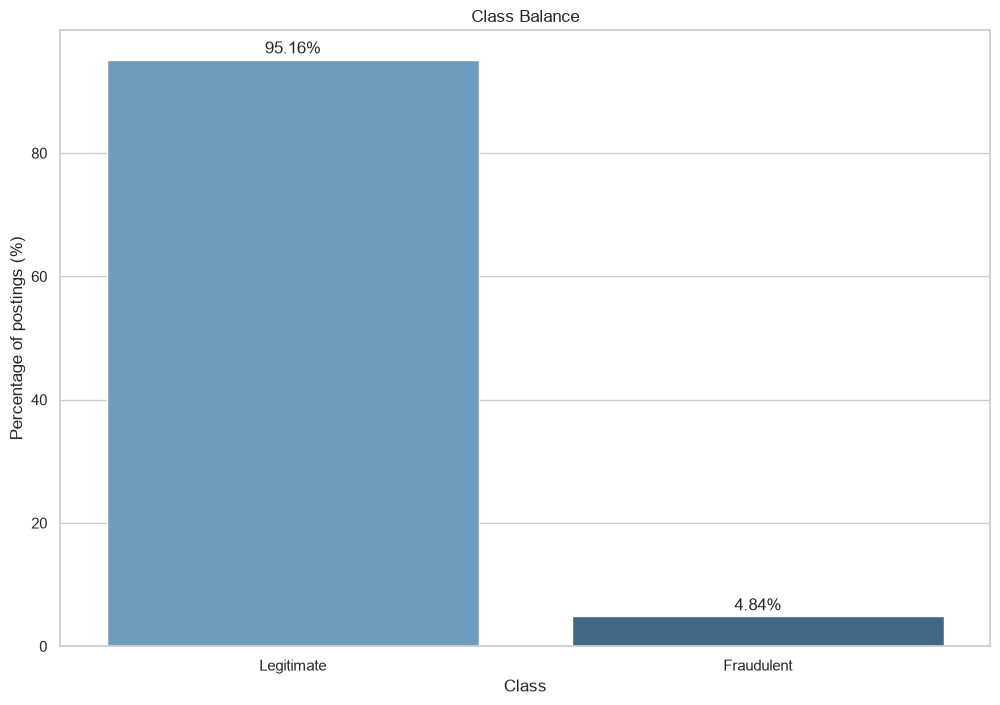

In [3]:
# Calculate the percentage of postings in each class
class_percentages = df["fraudulent"].value_counts(normalize=True).sort_index() * 100
class_labels = ["Legitimate", "Fraudulent"]

# Plot the class balance, labelling each bar with its percentage
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x=class_labels, y=class_percentages.values, hue=class_labels, palette="Blues_d", legend=False, ax=ax)
for i, percentage in enumerate(class_percentages.values):
    ax.text(i, percentage + 1, f"{percentage:.2f}%", ha="center")

ax.set_xlabel("Class")
ax.set_ylabel("Percentage of postings (%)")
ax.set_title("Class Balance")
plt.show()

## Missing-Value Profile

`cleaned_df` already has every column with meaningful missing data either filled with the placeholder `"missing"` or dropped entirely, so it can no longer show the original missing values.

The raw dataset, `data/raw/fake_job_postings.csv`, is loaded separately into `raw_df`, and the chart is limited to the columns that had at least one missing value to ensure it reflects the same missing-value profile `01_data_understanding.ipynb` first found.

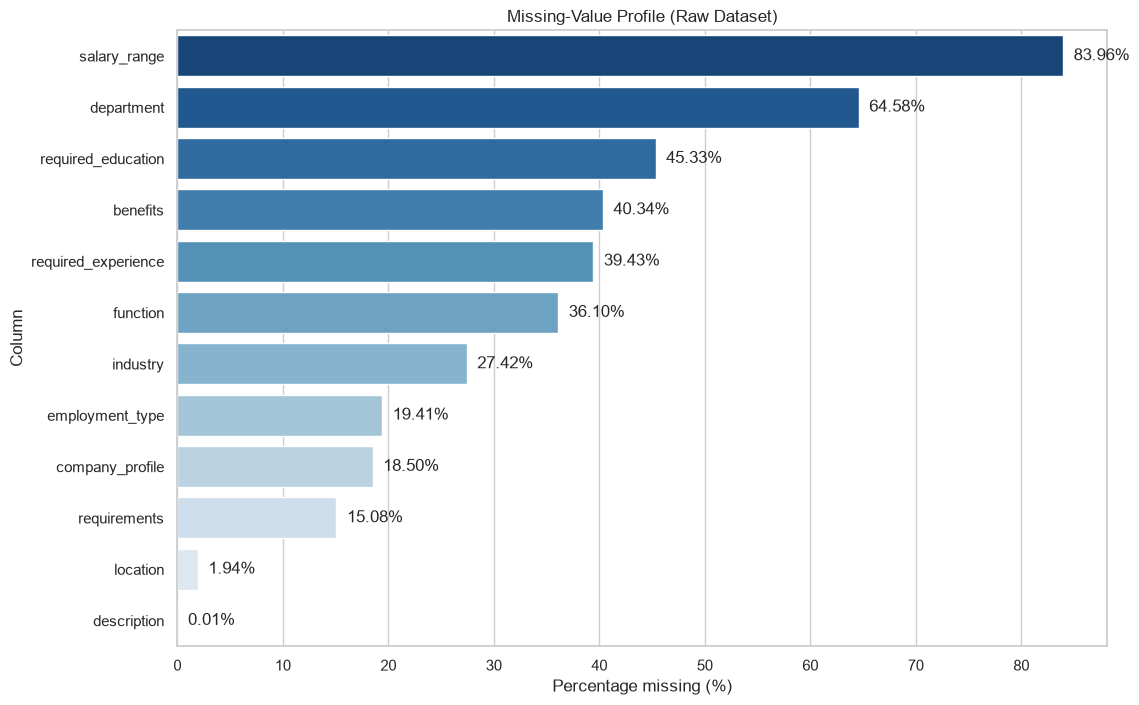

In [4]:
# Load the raw, pre-fill dataset for the missing-value chart only
raw_df = pd.read_csv("../data/raw/fake_job_postings.csv")

# Keep only the columns that have at least one missing value, sorted by percentage missing
missing_percentages = raw_df.isna().mean() * 100
missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

# Plot the missing-value profile as a horizontal bar chart, labelling each bar with its percentage
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x=missing_percentages.values, y=missing_percentages.index, hue=missing_percentages.index, palette="Blues_r", legend=False, ax=ax)
for i, percentage in enumerate(missing_percentages.values):
    ax.text(percentage + 1, i, f"{percentage:.2f}%", va="center")

ax.set_xlabel("Percentage missing (%)")
ax.set_ylabel("Column")
ax.set_title("Missing-Value Profile (Raw Dataset)")
plt.show()

## Text Length by Class

`01_data_understanding.ipynb` measured the length of each raw text field overall, but not split by class. The character length of the cleaned `text` column is compared between legitimate and fraudulent postings to check whether fraudulent postings tend to be noticeably shorter or longer.

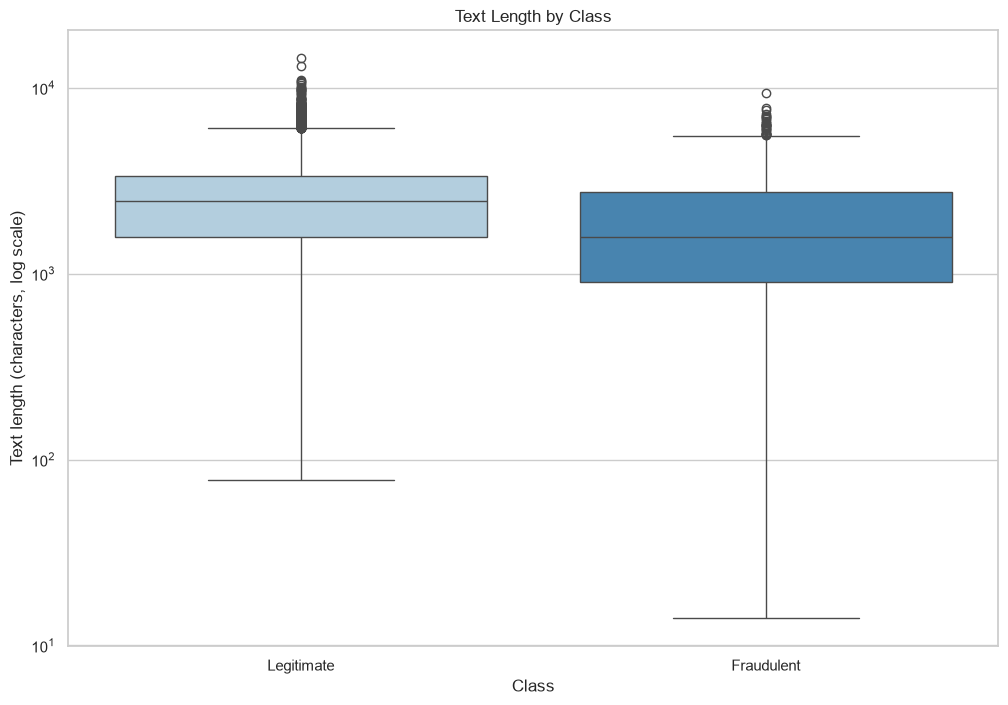

In [5]:
# Measure the character length of the cleaned text column
df["text_length"] = df["text"].str.len()

# Plot text length by class as a boxplot: a logarithmic scale is used to keep a handful of very long postings notebook 01 already found from squashing the rest of the distribution flat
fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(x=df["fraudulent"].map({0: "Legitimate", 1: "Fraudulent"}), y=df["text_length"], hue=df["fraudulent"].map({0: "Legitimate", 1: "Fraudulent"}), palette="Blues", legend=False, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Class")
ax.set_ylabel("Text length (characters, log scale)")
ax.set_title("Text Length by Class")
plt.show()

## Fraud Rate by Metadata Field

`01_data_understanding.ipynb` already computed the fraud rate within each category of the six metadata columns as text, and flagged that some categories (for example "Some High School Coursework" at 74.07%) are backed by only a handful of postings making them unreliable.

To keep that same caution here, each field's chart is limited to its eight highest-count categories, so every bar shown represents a category with enough postings behind it to be a real signal rather than small-sample noise.

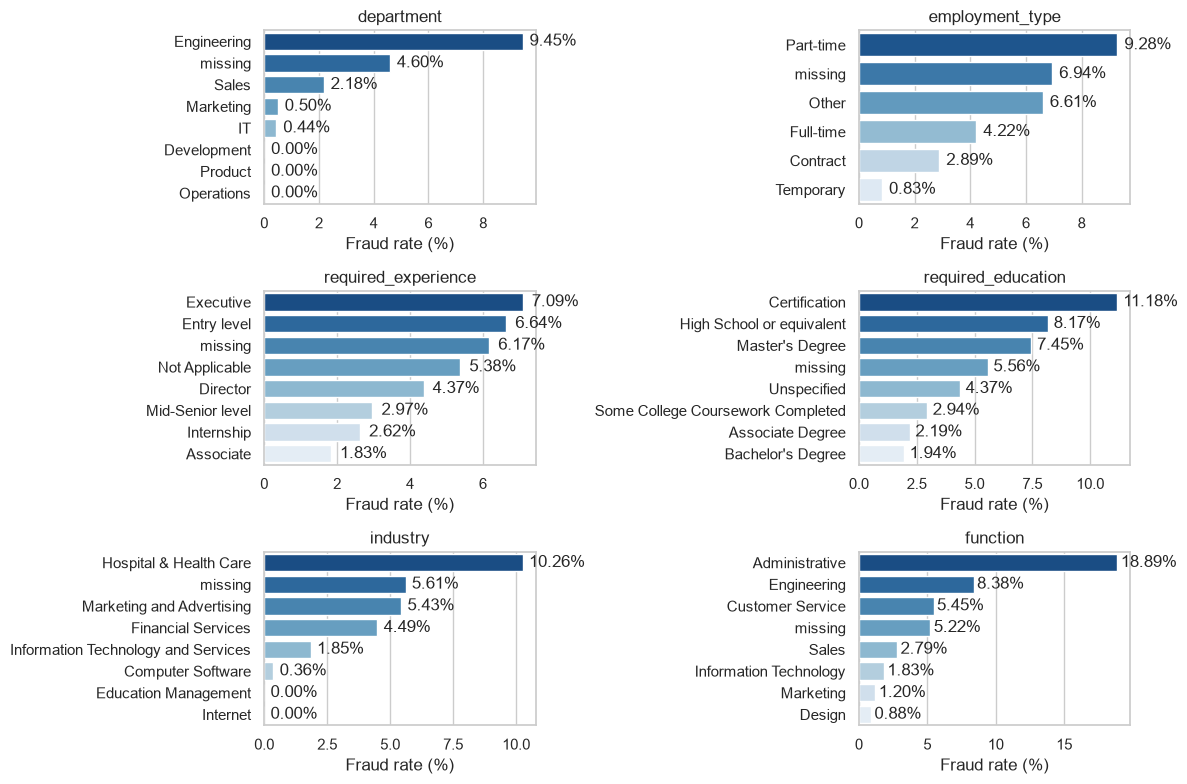

In [6]:
# Plot fraud rate by category for each metadata field, limited to the eight highest-count categories
metadata_fields = ["department", "employment_type", "required_experience", "required_education", "industry", "function"]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for field, ax in zip(metadata_fields, axes.flat):
    top_categories = df[field].value_counts().head(8).index
    fraud_rate_by_category = df[df[field].isin(top_categories)].groupby(field)["fraudulent"].mean().sort_values(ascending=False) * 100

    sns.barplot(x=fraud_rate_by_category.values, y=fraud_rate_by_category.index, hue=fraud_rate_by_category.index, palette="Blues_r", legend=False, ax=ax)
    for i, percentage in enumerate(fraud_rate_by_category.values):
        ax.text(percentage + 0.25, i, f"{percentage:.2f}%", va="center")

    ax.set_xlabel("Fraud rate (%)")
    ax.set_ylabel("")
    ax.set_title(field)

plt.tight_layout()
plt.show()

The three binary flags are complete columns (no missing values), so every posting contributes to both bars of each chart, unlike the metadata fields above. `01_data_understanding.ipynb` already found a visible split for all three, with `has_company_logo` the strongest.

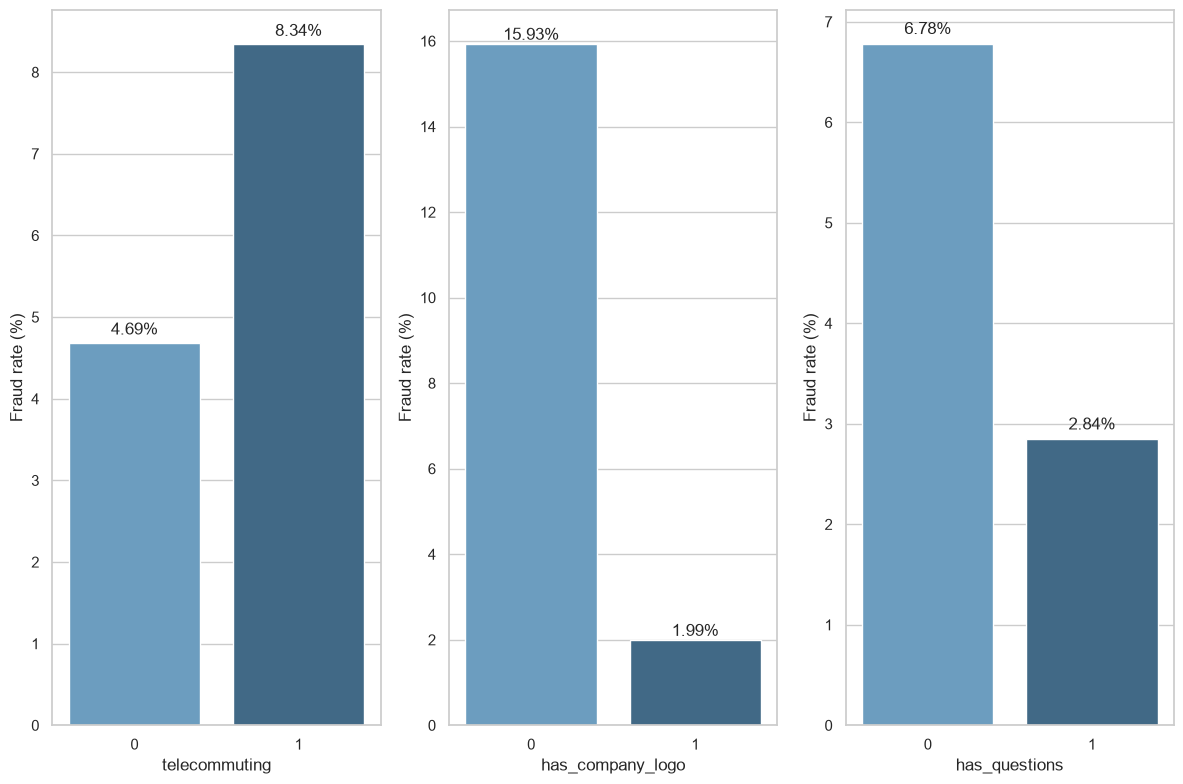

In [7]:
# Plot fraud rate by category for each binary flag
binary_fields = ["telecommuting", "has_company_logo", "has_questions"]

fig, axes = plt.subplots(1, 3, figsize=(12, 8))
for field, ax in zip(binary_fields, axes):
    fraud_rate_by_flag = df.groupby(field)["fraudulent"].mean().sort_index() * 100

    sns.barplot(x=fraud_rate_by_flag.index.astype(str), y=fraud_rate_by_flag.values, hue=fraud_rate_by_flag.index.astype(str), palette="Blues_d", legend=False, ax=ax)
    for i, percentage in enumerate(fraud_rate_by_flag.values):
        ax.text(i, percentage + 0.1, f"{percentage:.2f}%", ha="center")

    ax.set_xlabel(field)
    ax.set_ylabel("Fraud rate (%)")

plt.tight_layout()
plt.show()

## Most Distinctive Words per Class

A single `TfidfVectorizer` is fitted on the whole cleaned `text` column, with English stop words removed so common words like "the" or "and" do not crowd out more informative ones. This is a descriptive statistic built purely to produce this chart, not a component that will be reused for prediction. `04_modelling_classical.ipynb` fits its own vectoriser on the training split only, so this does not conflict with fitting only after a split.

The average TF-IDF score of each word is calculated separately within each class, and the fifteen highest-scoring words for legitimate and for fraudulent postings are plotted side by side, showing which words are most distinctive for each class.

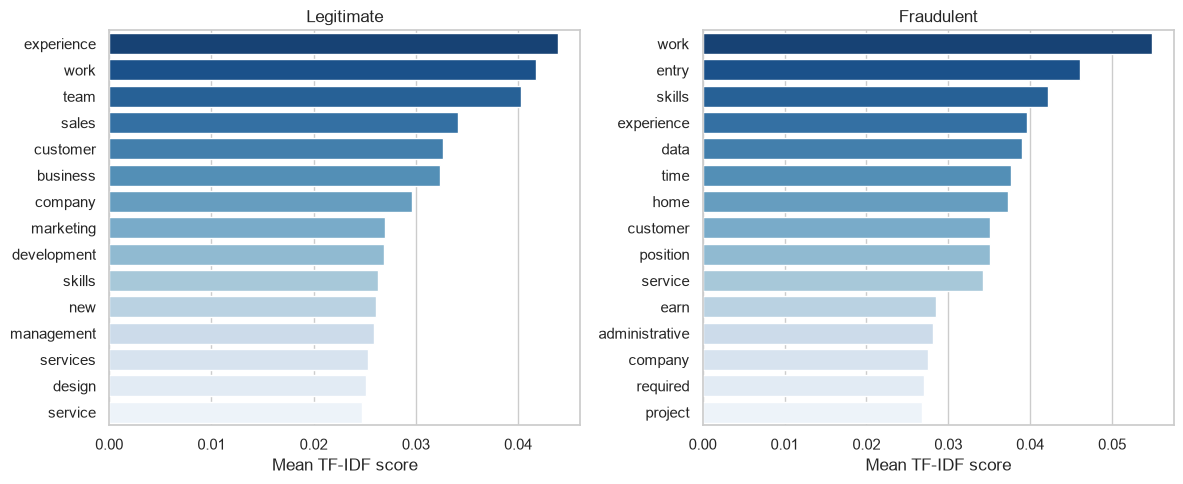

In [8]:
# Fit a TF-IDF vectorizer on the whole cleaned text column, purely to build this chart
vectorizer = TfidfVectorizer(stop_words="english", max_features=2000)
tfidf_matrix = vectorizer.fit_transform(df["text"])
feature_names = vectorizer.get_feature_names_out()

# Compute the average TF-IDF score of each word within each class, then take the top fifteen
top_words_by_class = {}
for label, class_name in [(0, "Legitimate"), (1, "Fraudulent")]:
    class_mean_tfidf = tfidf_matrix[df["fraudulent"].values == label].mean(axis=0)
    class_mean_tfidf = pd.Series(class_mean_tfidf.A1, index=feature_names)
    top_words_by_class[class_name] = class_mean_tfidf.sort_values(ascending=False).head(15)

# Plot the top words for each class side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (class_name, top_words) in zip(axes, top_words_by_class.items()):
    sns.barplot(x=top_words.values, y=top_words.index, hue=top_words.index, palette="Blues_r", legend=False, ax=ax)
    ax.set_xlabel("Mean TF-IDF score")
    ax.set_ylabel("")
    ax.set_title(class_name)

plt.tight_layout()
plt.show()

## Summary

- Visualised the class balance (95.16% legitimate versus 4.84% fraudulent), the same imbalance that justifies `class_weight="balanced"` in `04_modelling_classical.ipynb`.
- Charted the missing-value profile from a raw, pre-fill snapshot, since `cleaned_df` has already filled or dropped every column with meaningful missing values.
- Compared cleaned text length between legitimate and fraudulent postings (see the chart above for the exact distributions).
- Charted fraud rate by category for the six metadata fields (restricted to each field's highest-count categories, to avoid the small-sample noise `01_data_understanding.ipynb` already flagged) and for the three binary flags.
- Fitted a `TfidfVectorizer` on the whole cleaned `text` column purely to chart the fifteen most distinctive words per class; this vectoriser is not reused for prediction.
- No data was cleaned, split, or fitted for modelling in this notebook. Every chart is a descriptive statistic. `04_modelling_classical.ipynb` performs the train/validation/test split and fits the deployed pipeline components.